In [3]:
!pip install matplotlib

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

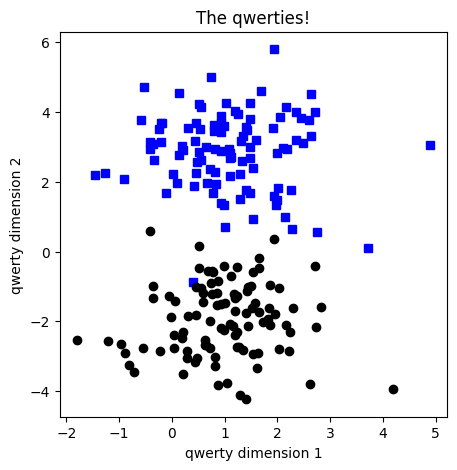

In [14]:
# create data

nPerClust = 100
blur = 1

A = [  1,  3 ]
B = [  1, -2 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [53]:
def createANNModel(learningRate):

  ANNclassify = nn.Sequential(
      nn.Linear(2,16),
      # nn.ReLU(),
      nn.Linear(16,1),
      # nn.ReLU(),
      nn.Linear(1,1),
      nn.Sigmoid(),
    )

  lossfun = nn.BCELoss()
  optimizer = torch.optim.SGD(ANNclassify.parameters(),lr=learningRate)
  return ANNclassify, lossfun, optimizer

In [54]:
learningRate = .01



numepochs = 1000



def trainModel(ANNModel, lossfun, optimizer):

  losses=torch.zeros(numepochs, 1)
  for epochi in range(numepochs):

    # forward pass
    yHat = ANNModel(data)

    # compute loss
    loss = lossfun(yHat,labels)
    losses[epochi] = loss

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  predictions = ANNclassify(data)
  total_acc=100*torch.mean(((predictions > 0.5) == labels).float())
  return losses, predictions, total_acc



# bool_pred=yHat>0.5
# print('yHat', yHat)
lrs = torch.linspace(0.001, 0.2, 50)
final_acc=torch.zeros(len(lrs), 1)
accuracy_by_lr=torch.zeros(len(lrs), numepochs)

for i,lr in enumerate(lrs):
  ANNclassify,lossfun,optimizer = createANNModel(lr)
  losses, predictions, total_acc=trainModel(ANNclassify,lossfun,optimizer)
  final_acc[i] = total_acc
  # accuracy_by_lr[i:] = losses.T

<Figure size 640x480 with 0 Axes>

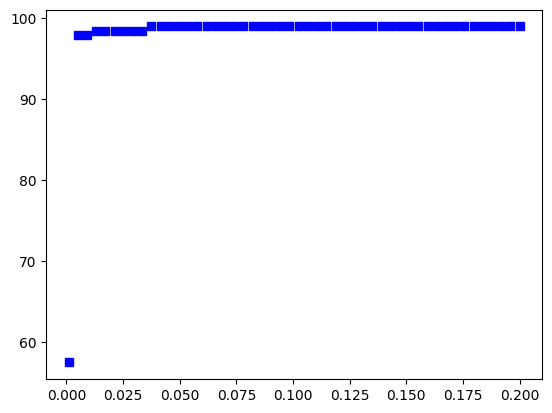

<Figure size 640x480 with 0 Axes>

In [56]:
plt.plot(lrs.detach(),final_acc.detach(),'bs')
plt.figure()
# plt.plot(accuracy_by_lr.detach().numpy())

In [8]:
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
iris = sns.load_dataset('iris')

In [99]:
data=torch.tensor(iris[iris.columns[0:4]].values).float()
labels=torch.zeros(len(data), dtype=torch.long)
labels[iris.species == 'versicolor'] = 1
labels[iris.species == 'virginica'] = 2

import torch.nn as nn
def createModel(nodes_num):
  ANNIris = nn.Sequential(
      nn.Linear(4,nodes_num),
      nn.ReLU(),
      nn.Linear(nodes_num,nodes_num),
      nn.ReLU(),
      nn.Linear(nodes_num,3)
    )

  lossfun = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(ANNIris.parameters(),lr=0.1)
  return lossfun, ANNIris, optimizer


def trainModel(Model, lossfun, optimizer):

  numepochs=150
  loses=torch.zeros(numepochs)
  ongoingAcc=[]

  for epochi in range(numepochs):

    # forward pass
    yHat = Model(data)

    # compute loss
    loss = lossfun(yHat,labels)
    loses[epochi] = loss
    # break
    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # matches=torch.argmax(yHat, dim=1) == labels
    # matches_num=matches.float()
    # general_acc=100*torch.mean(matches_num)
    # ongoingAcc.append(general_acc)


In [100]:

max_num_nodes=128
progressive_acc=[]
for node_n in range(1,max_num_nodes+1):
  lossfun, ANNIris, optimizer = createModel(node_n)
  trainModel(ANNIris, lossfun, optimizer)

  pred=ANNIris(data)
  matches=torch.argmax(pred, dim=1) == labels
  matches_num=matches.float()
  general_acc=100*torch.mean(matches_num)
  progressive_acc.append(general_acc)



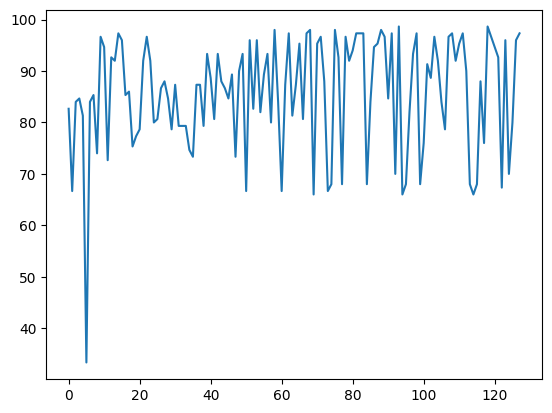

In [101]:
# probs = torch.softmax(yHat, dim=1)
# print(probs)
# plt.plot(loses.detach())
# plt.figure()
plt.plot(progressive_acc)

label_exam tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 

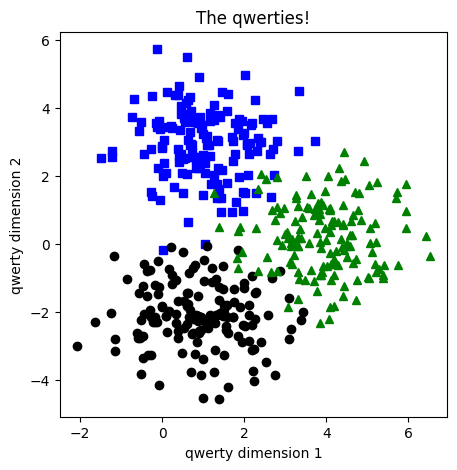

In [77]:
import numpy as np

nPerClust = 150
blur = 1

A = [  1,  3 ]
B = [  1, -2 ]
C = [  4, 0.5 ]

a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]


# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)), np.ones((nPerClust,1)), np.full((nPerClust, 1), 2)))

# concatanate into a matrix
data_np = np.hstack((a,b,c)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()

labels = torch.tensor(labels_np).long().squeeze()
# labels = labels.squeeze().long()
print('label_exam', labels)

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'g^')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [85]:
ANNclassify = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,16),
    nn.ReLU(),
    nn.Linear(16,3),
  )

lossfun = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(ANNclassify.parameters(),lr=0.01)
ongoingAcc=[]

numepochs=3000
loses=torch.zeros(numepochs)
# print("yHat", data.size())
print(labels.shape, labels.dtype)
for epochi in range(numepochs):

  # forward pass
  yHat = ANNclassify(data)
  # print("yHat", yHat.size())
  # print("labels", labels.size())
  # break
  # compute loss
  loss = lossfun(yHat,labels)
  loses[epochi] = loss
  # break
  # backprop
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  matches = torch.argmax(yHat, dim=1) == labels
  matches_num=matches.float()
  general_acc=100*torch.mean(matches_num)
  ongoingAcc.append(general_acc)

torch.Size([450]) torch.int64


predictions tensor([[ 6.3192, -4.9966, -0.7508],
        [ 9.0550, -6.1805, -2.2481],
        [ 7.2531, -4.5986, -2.1160],
        ...,
        [-2.1620, -1.5254,  4.1749],
        [-3.4944,  1.6155,  2.2603],
        [-2.3060, -1.8932,  4.7337]], grad_fn=<AddmmBackward0>)
probs tensor([[9.9914e-01, 1.2168e-05, 8.4947e-04],
        [9.9999e-01, 2.4171e-07, 1.2335e-05],
        [9.9991e-01, 7.1252e-06, 8.5308e-05],
        ...,
        [1.7606e-03, 3.3279e-03, 9.9491e-01],
        [2.0732e-03, 3.4343e-01, 6.5450e-01],
        [8.7447e-04, 1.3214e-03, 9.9780e-01]], grad_fn=<SoftmaxBackward0>)


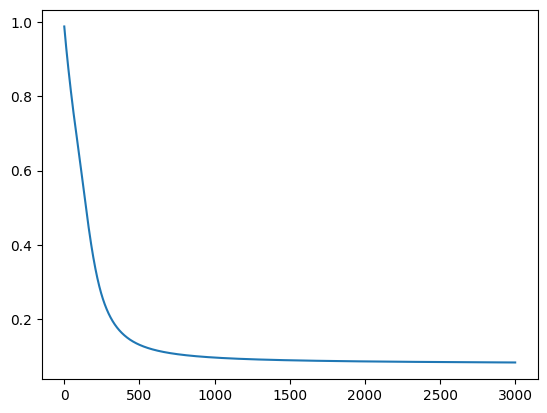

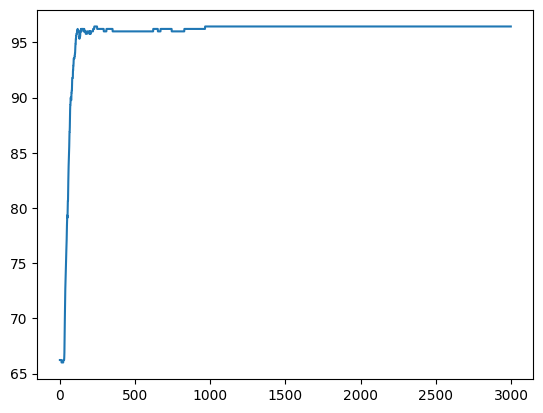

In [87]:
predictions=ANNclassify(data)
probs = torch.softmax(predictions, dim=1)
print("predictions", predictions)
print("probs", probs)


plt.plot(loses.detach())
plt.figure()
plt.plot(ongoingAcc)

In [103]:
breadth=nn.Sequential(
    nn.Linear(2,4),
    nn.Linear(4,3)
  )

deep=nn.Sequential(
    nn.Linear(2,2),
    nn.Linear(2,2),
    nn.Linear(2,3)
  )

for p in breadth.named_parameters():
  print(p)

('0.weight', Parameter containing:
tensor([[ 0.1049,  0.3882],
        [ 0.2895, -0.4458],
        [-0.3405, -0.2563],
        [-0.0457, -0.1878]], requires_grad=True))
('0.bias', Parameter containing:
tensor([-0.3202, -0.3956,  0.5270, -0.1125], requires_grad=True))
('1.weight', Parameter containing:
tensor([[-0.2002, -0.4996, -0.1388,  0.0038],
        [-0.0274,  0.0922,  0.3004, -0.2283],
        [-0.0779,  0.1894, -0.2482, -0.1006]], requires_grad=True))
('1.bias', Parameter containing:
tensor([ 0.0151, -0.4417,  0.4933], requires_grad=True))
